# **Libraries**

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

# **Import tracks from APERO**

In [2]:
# import TZEX sinking speed (APERO, vlfr)
APERO = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/APERO_selected_tracks_by_interquartile_poly_no_living.csv', delimiter = ",")

APERO['cruise'] = 'APERO'
APERO['zone'] = 'North Atlantic (TZEX)'
APERO = APERO[['esd_um', 'corrected_by_poly', 'zone']]
APERO['type'] = 'TZEX-UVP6'
APERO['In/Ex'] = 'In'
APERO = APERO.rename(columns={'corrected_by_poly': 'speed'})
APERO.head(5)

,esd_um,speed,zone,type,In/Ex
0,246.547642,75.065237,North Atlantic (TZEX),TZEX-UVP6,In
1,1035.906803,78.591289,North Atlantic (TZEX),TZEX-UVP6,In
2,108.968921,98.552216,North Atlantic (TZEX),TZEX-UVP6,In
3,136.415389,81.530760,North Atlantic (TZEX),TZEX-UVP6,In
4,124.092221,89.085797,North Atlantic (TZEX),TZEX-UVP6,In


# **Import tracks from VLFR**

In [3]:
vlfr = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/VLFR_selected_tracks_by_interquartile_poly_no_living.csv')
vlfr['cruise'] = 'vlfr'
vlfr['zone'] = 'Mediterranean Sea (TZEX)'
vlfr = vlfr[['esd_um', 'corrected_by_poly', 'zone']]
vlfr = vlfr.rename(columns={'corrected_by_poly': 'speed'})
vlfr['type'] = 'TZEX-UVP6'
vlfr['In/Ex'] = 'In'
vlfr

,esd_um,speed,zone,type,In/Ex
0,114.971982,-73.375225,Mediterranean Sea (TZEX),TZEX-UVP6,In
1,455.286457,91.721063,Mediterranean Sea (TZEX),TZEX-UVP6,In
2,304.382251,63.854057,Mediterranean Sea (TZEX),TZEX-UVP6,In
3,363.951173,77.394113,Mediterranean Sea (TZEX),TZEX-UVP6,In
4,496.847746,68.070449,Mediterranean Sea (TZEX),TZEX-UVP6,In
...,...,...,...,...,...
461,195.102155,-56.134440,Mediterranean Sea (TZEX),TZEX-UVP6,In
462,205.712784,-69.149905,Mediterranean Sea (TZEX),TZEX-UVP6,In
463,191.745555,-56.078112,Mediterranean Sea (TZEX),TZEX-UVP6,In
464,124.717871,36.758480,Mediterranean Sea (TZEX),TZEX-UVP6,In


# **Import tracks from MBARI**

In [4]:
MBARI_tracks = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/MBARI_selected_tracks_by_interquartile_poly_no_living.csv')
MBARI_tracks['cruise'] = 'MBARI'
MBARI_tracks['zone'] = 'Monterey Bay (TZEX)'
MBARI_tracks = MBARI_tracks[['esd_um', 'corrected_by_poly', 'zone']]
MBARI_tracks['type'] = 'TZEX-UVP6'
MBARI_tracks['In/Ex'] = 'In'

MBARI_tracks = MBARI_tracks.rename(columns={'corrected_by_poly': 'speed'})
MBARI_tracks

,esd_um,speed,zone,type,In/Ex
0,319.153410,92.485980,Monterey Bay (TZEX),TZEX-UVP6,In
1,637.109978,-63.465722,Monterey Bay (TZEX),TZEX-UVP6,In
2,321.356039,-68.150954,Monterey Bay (TZEX),TZEX-UVP6,In
3,286.954110,-71.411880,Monterey Bay (TZEX),TZEX-UVP6,In
4,174.511074,48.391597,Monterey Bay (TZEX),TZEX-UVP6,In
...,...,...,...,...,...
431,406.879633,139.582284,Monterey Bay (TZEX),TZEX-UVP6,In
432,346.121564,133.486366,Monterey Bay (TZEX),TZEX-UVP6,In
433,456.019570,114.145864,Monterey Bay (TZEX),TZEX-UVP6,In
434,1168.870102,104.551268,Monterey Bay (TZEX),TZEX-UVP6,In


# **Import in situ data from Williams and Giering, 2022**

In [5]:
litterature = pd.read_csv('/home/aaccardo/these_alex/Analysis/APERO/TZEX/TZEX_vs_litterature/Data/in_situ_sinking_speed_Williams_Giering_2022.csv', delimiter = ";")
litterature = litterature.rename(columns={'in_situ_vertical_speed_m_d': 'speed', 'Location':'zone'})
litterature = litterature[['esd_um', 'speed', 'zone']]
litterature['esd_um'] = litterature['esd_um']*1000
litterature

,esd_um,speed,zone
0,7674.76,48.3663,Santa Barbara Channel
1,12808.40,49.3427,Santa Barbara Channel
2,13376.80,60.4929,Santa Barbara Channel
3,12875.50,127.9770,Santa Barbara Channel
4,12588.80,183.4550,Santa Barbara Channel
...,...,...,...
395,1065.90,80.4903,PAP Observatory
396,1183.20,150.9930,PAP Observatory
397,1197.90,38.7763,PAP Observatory
398,1674.20,117.0340,PAP Observatory


# **Combine them all**

In [6]:
combined_df = pd.concat([APERO, vlfr, MBARI_tracks, litterature], axis=0, ignore_index=True)
combined_df['study'] = combined_df['zone'].apply(
    lambda x: 'TZEX' if x in ['North Atlantic (TZEX)', 'Mediterranean Sea (TZEX)', 'Monterey Bay (TZEX)'] else 'Litterature'
)
combined_df

,esd_um,speed,zone,type,In/Ex,study
0,246.547642,75.065237,North Atlantic (TZEX),TZEX-UVP6,In,TZEX
1,1035.906803,78.591289,North Atlantic (TZEX),TZEX-UVP6,In,TZEX
2,108.968921,98.552216,North Atlantic (TZEX),TZEX-UVP6,In,TZEX
3,136.415389,81.530760,North Atlantic (TZEX),TZEX-UVP6,In,TZEX
4,124.092221,89.085797,North Atlantic (TZEX),TZEX-UVP6,In,TZEX
...,...,...,...,...,...,...
2093,1065.900000,80.490300,PAP Observatory,NaN,NaN,Litterature
2094,1183.200000,150.993000,PAP Observatory,NaN,NaN,Litterature
2095,1197.900000,38.776300,PAP Observatory,NaN,NaN,Litterature
2096,1674.200000,117.034000,PAP Observatory,NaN,NaN,Litterature


# **Select only descending tracks to compare with the literature**

In [7]:
desc_tracks_insitu = combined_df[combined_df['speed'] >= 0]
desc_tracks_insitu

,esd_um,speed,zone,type,In/Ex,study
0,246.547642,75.065237,North Atlantic (TZEX),TZEX-UVP6,In,TZEX
1,1035.906803,78.591289,North Atlantic (TZEX),TZEX-UVP6,In,TZEX
2,108.968921,98.552216,North Atlantic (TZEX),TZEX-UVP6,In,TZEX
3,136.415389,81.530760,North Atlantic (TZEX),TZEX-UVP6,In,TZEX
4,124.092221,89.085797,North Atlantic (TZEX),TZEX-UVP6,In,TZEX
...,...,...,...,...,...,...
2093,1065.900000,80.490300,PAP Observatory,NaN,NaN,Litterature
2094,1183.200000,150.993000,PAP Observatory,NaN,NaN,Litterature
2095,1197.900000,38.776300,PAP Observatory,NaN,NaN,Litterature
2096,1674.200000,117.034000,PAP Observatory,NaN,NaN,Litterature


In [8]:
desc_tracks_insitu['zone'].unique()

array(['North Atlantic (TZEX)', 'Mediterranean Sea (TZEX)',
       'Monterey Bay (TZEX)', 'Santa Barbara Channel',
       'California Current', 'Bahamas', 'Cape Blanc (Mauritania)',
       'Monterey Bay (+NE Atl.)', 'W Antarctic Peninsula',
       'Southern Ocean', 'PAP Observatory'], dtype=object)

# **Function to plot in situ sinking speed vs our data**

In [9]:
def plot_in_situ_sinking_speeds(data, x_col, y_col, zone_col, xlabel, ylabel, subplot_indice, ax, legend_ncol=5): # figsize=(15, 15)
    """
    Plots a scatter plot of sinking speeds vs ESD (or another variable) by zone.
    
    Parameters:
    - data (DataFrame): The input dataset containing the necessary columns.
    - x_col (str): Column name for the x-axis values.
    - y_col (str): Column name for the y-axis values.
    - zone_col (str): Column name for the categorical zones.
    - xlabel (str): Label for the x-axis.
    - ylabel (str): Label for the y-axis.
    - figsize (tuple): Size of the figure.
    - legend_ncol (int): Number of columns for the legend.
    """
    # Define colors for the zones
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', 
              '#ffff33', '#a65628', '#f781bf', '#999999', "#00BFC4", "#cb997e"]
    
    # Extract unique zones and map them to colors
    zones = data[zone_col].unique()
    zone_color_map = {zone: color for zone, color in zip(zones, colors)}
    
    # Create figure and axis
    #fig, ax = plt.subplots(figsize=figsize)
    ax.grid(True, which="both", ls="--", linewidth=1, zorder = 1)
    
    # Iterate through zones and plot scatter points
    for zone in ['Santa Barbara Channel', 'California Current', 'Bahamas',
       'Cape Blanc (Mauritania)', 'Monterey Bay (+NE Atl.)',
       'W Antarctic Peninsula', 'Southern Ocean', 'PAP Observatory', 'North Atlantic (TZEX)', 'Mediterranean Sea (TZEX)', 'Monterey Bay (TZEX)']:
        df_zone = data[data[zone_col] == zone]
        alpha = 1  # Adjust if needed
        
        ax.scatter(df_zone[x_col], df_zone[y_col],
                   c=zone_color_map[zone], marker="o", s=300,
                   edgecolor='black', alpha=alpha, zorder = 2)
        
        # Add legend entry
        ax.scatter([], [], color=zone_color_map[zone], label=f'{zone}', 
                   marker="o", s=300, alpha=alpha, edgecolor='black')
    
    # Set log scale for axes
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Labels and formatting
    size = 40
    pad = 15
    ax.set_xlabel(xlabel, fontsize=size)
    ax.set_ylabel(ylabel, fontsize=size)
    
    l = 8
    w = 3
    ax.tick_params(axis='y', labelsize=size-5, pad=pad, length=l, width=w)
    ax.tick_params(axis='x', labelsize=size-5, pad=pad, length=l, width=w)
    
    # Legend settings
    ax.legend(labelspacing=0.25, markerscale=1, handletextpad=0.25, 
              borderpad=0.25, columnspacing=0.25, edgecolor='black', frameon=True, framealpha=1, 
              fancybox=True, shadow=True, ncol=legend_ncol, loc='lower center', fontsize = 17)
    
    # Subplot indice 
    ax.text(0.04,  0.95, f'{subplot_indice}', color='black', 
         fontsize=50, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
         alpha = 1, transform=ax.transAxes)  
    
    # Set the line width for all spines
    for spine in ax.spines.values():
        spine.set_linewidth(4)
    
    #plt.show()

# **Import all sinking speed data (in situ + ex situ) from Williams and Giering, 2022**

In [10]:
lit_sv = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Literature_data_Williams_Giering_2022/data_sv_Williams_Giering.csv', delimiter = ';')
lit_sv['ESD (mm)'] = lit_sv['ESD (mm)']*1000
lit_sv = lit_sv.rename(columns={'ESD (mm)': 'esd_um', 'SV (m/d)':'speed', 'Study number' : 'id'})
lit_sv['id'] = pd.to_numeric(lit_sv['id'])
lit_sv

,id,esd_um,speed
0,1.0,7674.760000,48.366300
1,1.0,12808.400000,49.342700
2,1.0,13376.800000,60.492900
3,1.0,12875.500000,127.977000
4,1.0,12588.800000,183.455000
...,...,...,...
4772,38.2,3734.570854,219.174490
4773,38.2,4046.502727,238.116501
4774,38.2,2900.200938,230.993313
4775,38.2,1942.397857,262.696818


In [11]:
# add metadata
metadata = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Literature_data_Williams_Giering_2022/Williams_Giering_metadata.csv', delimiter = ';')
metadata = metadata.rename(columns={'paper number' : 'id', 'location':'zone'})
metadata['id'] = pd.to_numeric(metadata['id'])
metadata

,id,zone,In/Ex
0,1.0,Santa Barbara Channel,In
1,2.0,California Current,In
2,3.1,Bedford Basin,Ex
3,3.2,Lab,Ex
4,4.0,Cape Blanc (Mauritania),Ex
...,...,...,...
58,35.3,Lab,Ex
59,36.0,"Eureka, USA (Station S-60)",In
60,37.0,Lab,Ex
61,38.1,Lab,Ex


In [12]:
# merge them
lit_sv = pd.merge(lit_sv, metadata, on = 'id')
lit_sv = lit_sv.drop('id', axis=1)
lit_sv['type'] = 'Literature'
lit_sv = lit_sv.drop_duplicates()
lit_sv

,esd_um,speed,zone,In/Ex,type
0,7674.760000,48.366300,Santa Barbara Channel,In,Literature
1,12808.400000,49.342700,Santa Barbara Channel,In,Literature
2,13376.800000,60.492900,Santa Barbara Channel,In,Literature
3,12875.500000,127.977000,Santa Barbara Channel,In,Literature
4,12588.800000,183.455000,Santa Barbara Channel,In,Literature
...,...,...,...,...,...
6641,3734.570854,219.174490,Lab,Ex,Literature
6642,4046.502727,238.116501,Lab,Ex,Literature
6643,2900.200938,230.993313,Lab,Ex,Literature
6644,1942.397857,262.696818,Lab,Ex,Literature


# **Combine with TZEX data**

In [13]:
combined_df = pd.concat([APERO, vlfr, MBARI_tracks, lit_sv], axis=0, ignore_index=True)
combined_df['zone'].unique()

array(['North Atlantic (TZEX)', 'Mediterranean Sea (TZEX)',
       'Monterey Bay (TZEX)', 'Santa Barbara Channel',
       'California Current', 'Bedford Basin', 'Lab',
       'Cape Blanc (Mauritania)', 'Southern Ocean', 'PAP', 'Bahamas',
       'ETNP (Guatemala)', 'South Atlantic Bight',
       "Buzzard's bay // Osaka bay", 'Glacier bay',
       'Helgoland time series', 'Kuroshio', 'Coastal Baltic Sea',
       'North Adriatic Sea', 'Monterey Bay (+NE Atl.)', 'Ligurian Sea',
       'Naragansett Bay', 'W Antarctic Peninsula',
       'Southern California Bight'], dtype=object)

# **Select only descending tracks**

In [14]:
desc_tracks = combined_df[combined_df['speed'] >= 0]
desc_tracks = desc_tracks.dropna(subset=['In/Ex'])
desc_tracks

,esd_um,speed,zone,type,In/Ex
0,246.547642,75.065237,North Atlantic (TZEX),TZEX-UVP6,In
1,1035.906803,78.591289,North Atlantic (TZEX),TZEX-UVP6,In
2,108.968921,98.552216,North Atlantic (TZEX),TZEX-UVP6,In
3,136.415389,81.530760,North Atlantic (TZEX),TZEX-UVP6,In
4,124.092221,89.085797,North Atlantic (TZEX),TZEX-UVP6,In
...,...,...,...,...,...
6133,3734.570854,219.174490,Lab,Literature,Ex
6134,4046.502727,238.116501,Lab,Literature,Ex
6135,2900.200938,230.993313,Lab,Literature,Ex
6136,1942.397857,262.696818,Lab,Literature,Ex


In [24]:
def plot_sinking_speeds(df, xaxis_label, yaxis_label, subplot_indice, ax):
    """
    Plots vertical sinking speeds vs. ESD (µm) for different particle types.

    Parameters:
    - df: DataFrame containing columns ['esd_um', 'speed', 'type', 'In/Ex']
    - figsize: Tuple (width, height) for the figure
    - marker_size: Size of scatter plot markers
    - legend_size: Font size of the legend
    """

    #fig, ax = plt.subplots(figsize=(15, 15))

    # Define color mapping for 'type'
    colors = {'Literature': '#999999', 'TZEX-UVP6': "#10698D"}
    
    # Define marker mapping for 'In/Ex'
    markers = {'In': 'o', 'Ex': '*'}

    # Grid settings
    ax.grid(True, which="both", ls="--", linewidth=1, alpha=0.7, zorder=1)

    # Scatter plot for each type
    for type_ in colors.keys():
        
        if type_ == 'Literature':
            alpha = 0.3
        else:
            alpha = 1
            
        df_type = df[df['type'] == type_]
        
        ax.scatter(df_type['esd_um'], df_type['speed'], 
                   color=colors[type_], 
                   marker='o', 
                   alpha = alpha,
                   s=300, edgecolor='black', zorder=2)

        # Add legend entry with italicized count
        ax.scatter([], [], color=colors[type_],
                   label=f"{type_} " + r"$\mathit{(n=" + str(len(df_type)) + r")}$",
                   marker="o", s=300, alpha=alpha, edgecolor='black')

    # Log scale for both axes
    ax.set_xscale('log')
    ax.set_yscale('log')

    # Labels
    size = 50
    pad = 15
    ax.set_ylabel(f'{yaxis_label}', fontsize=size)
    ax.set_xlabel(f'{xaxis_label}', fontsize=size)

    # Tick parameters
    l = 8
    w = 3
    ax.tick_params(axis='y', labelsize=size-5, pad=pad, length=l, width=w)
    ax.tick_params(axis='x', labelsize=size-5, pad=pad, length=l, width=w)

    # Legend
    ax.legend(loc='lower right',
              labelspacing=1.5, fontsize=30,
              markerscale=1.5, handletextpad=1.5, borderpad=1,
              edgecolor='black', frameon=True, framealpha=1,
              fancybox=True, shadow=True, ncol=2) # bbox_to_anchor=(0.6, 0.05)
    
    # Subplot indice 
    ax.text(0.04,  0.95, f'{subplot_indice}', color='black', 
         fontsize=60, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
         alpha = 1, transform=ax.transAxes)  
    
    # Set spine width
    for spine in ax.spines.values():
        spine.set_linewidth(4)
    

In [27]:
def plot_in_situ_sinking_speeds(
    data, x_col, y_col, zone_col, xlabel, ylabel,
    subplot_indice, ax, legend_ncol=2
):
    """
    Scatter plot of sinking speeds vs ESD grouped into:
    - TZEX-UVP6
    - In situ (all other regions)
    """

    # --- Define TZEX zones ---
    tzex_zones = [
        'North Atlantic (TZEX)',
        'Mediterranean Sea (TZEX)',
        'Monterey Bay (TZEX)'
    ]

    # --- Colors ---
    color_tzex = "#10698D"
    color_insitu = '#999999'

    # --- Grid ---
    ax.grid(True, which="both", ls="--", linewidth=1, zorder=1)

    # --- Split datasets ---
    df_tzex = data[data[zone_col].isin(tzex_zones)]
    df_insitu = data[~data[zone_col].isin(tzex_zones)]

    # --- Scatter: In situ (background first) ---
    ax.scatter(
        df_insitu[x_col], df_insitu[y_col],
        color=color_insitu, marker="o", s=300,
        edgecolor='black', alpha=0.5, zorder=2
    )

    # --- Scatter: TZEX ---
    ax.scatter(
        df_tzex[x_col], df_tzex[y_col],
        color=color_tzex, marker="o", s=300,
        edgecolor='black', alpha=1, zorder=3
    )

    # --- Legend entries with italic n ---
    ax.scatter(
        [], [], color=color_insitu, alpha = 0.5,
        label="In situ " + rf"$\mathit{{(n={len(df_insitu)})}}$",
        marker="o", s=300, edgecolor='black'
    )

    ax.scatter(
        [], [], color=color_tzex, alpha = 1,
        label="TZEX-UVP6 " + rf"$\mathit{{(n={len(df_tzex)})}}$",
        marker="o", s=300, edgecolor='black'
    )

    # --- Log scales ---
    ax.set_xscale('log')
    ax.set_yscale('log')

    # --- Labels ---
    size = 50
    pad = 15
    ax.set_xlabel(xlabel, fontsize=size)
    ax.set_ylabel(ylabel, fontsize=size)

    l, w = 8, 3
    ax.tick_params(axis='y', labelsize=size-5, pad=pad, length=l, width=w)
    ax.tick_params(axis='x', labelsize=size-5, pad=pad, length=l, width=w)

    # --- Legend ---
    ax.legend(loc='lower right',
              labelspacing=1.5, fontsize=30,
              markerscale=1.5, handletextpad=1.5, borderpad=1,
              edgecolor='black', frameon=True, framealpha=1,
              fancybox=True, shadow=True, ncol=2)

    # --- Subplot indice ---
    ax.text(
        0.04, 0.95, subplot_indice,
        color='black', fontsize=60,
        ha='center', va='center',
        fontfamily='serif', fontweight='bold',
        transform=ax.transAxes
    )

    # --- Spine width ---
    for spine in ax.spines.values():
        spine.set_linewidth(4)

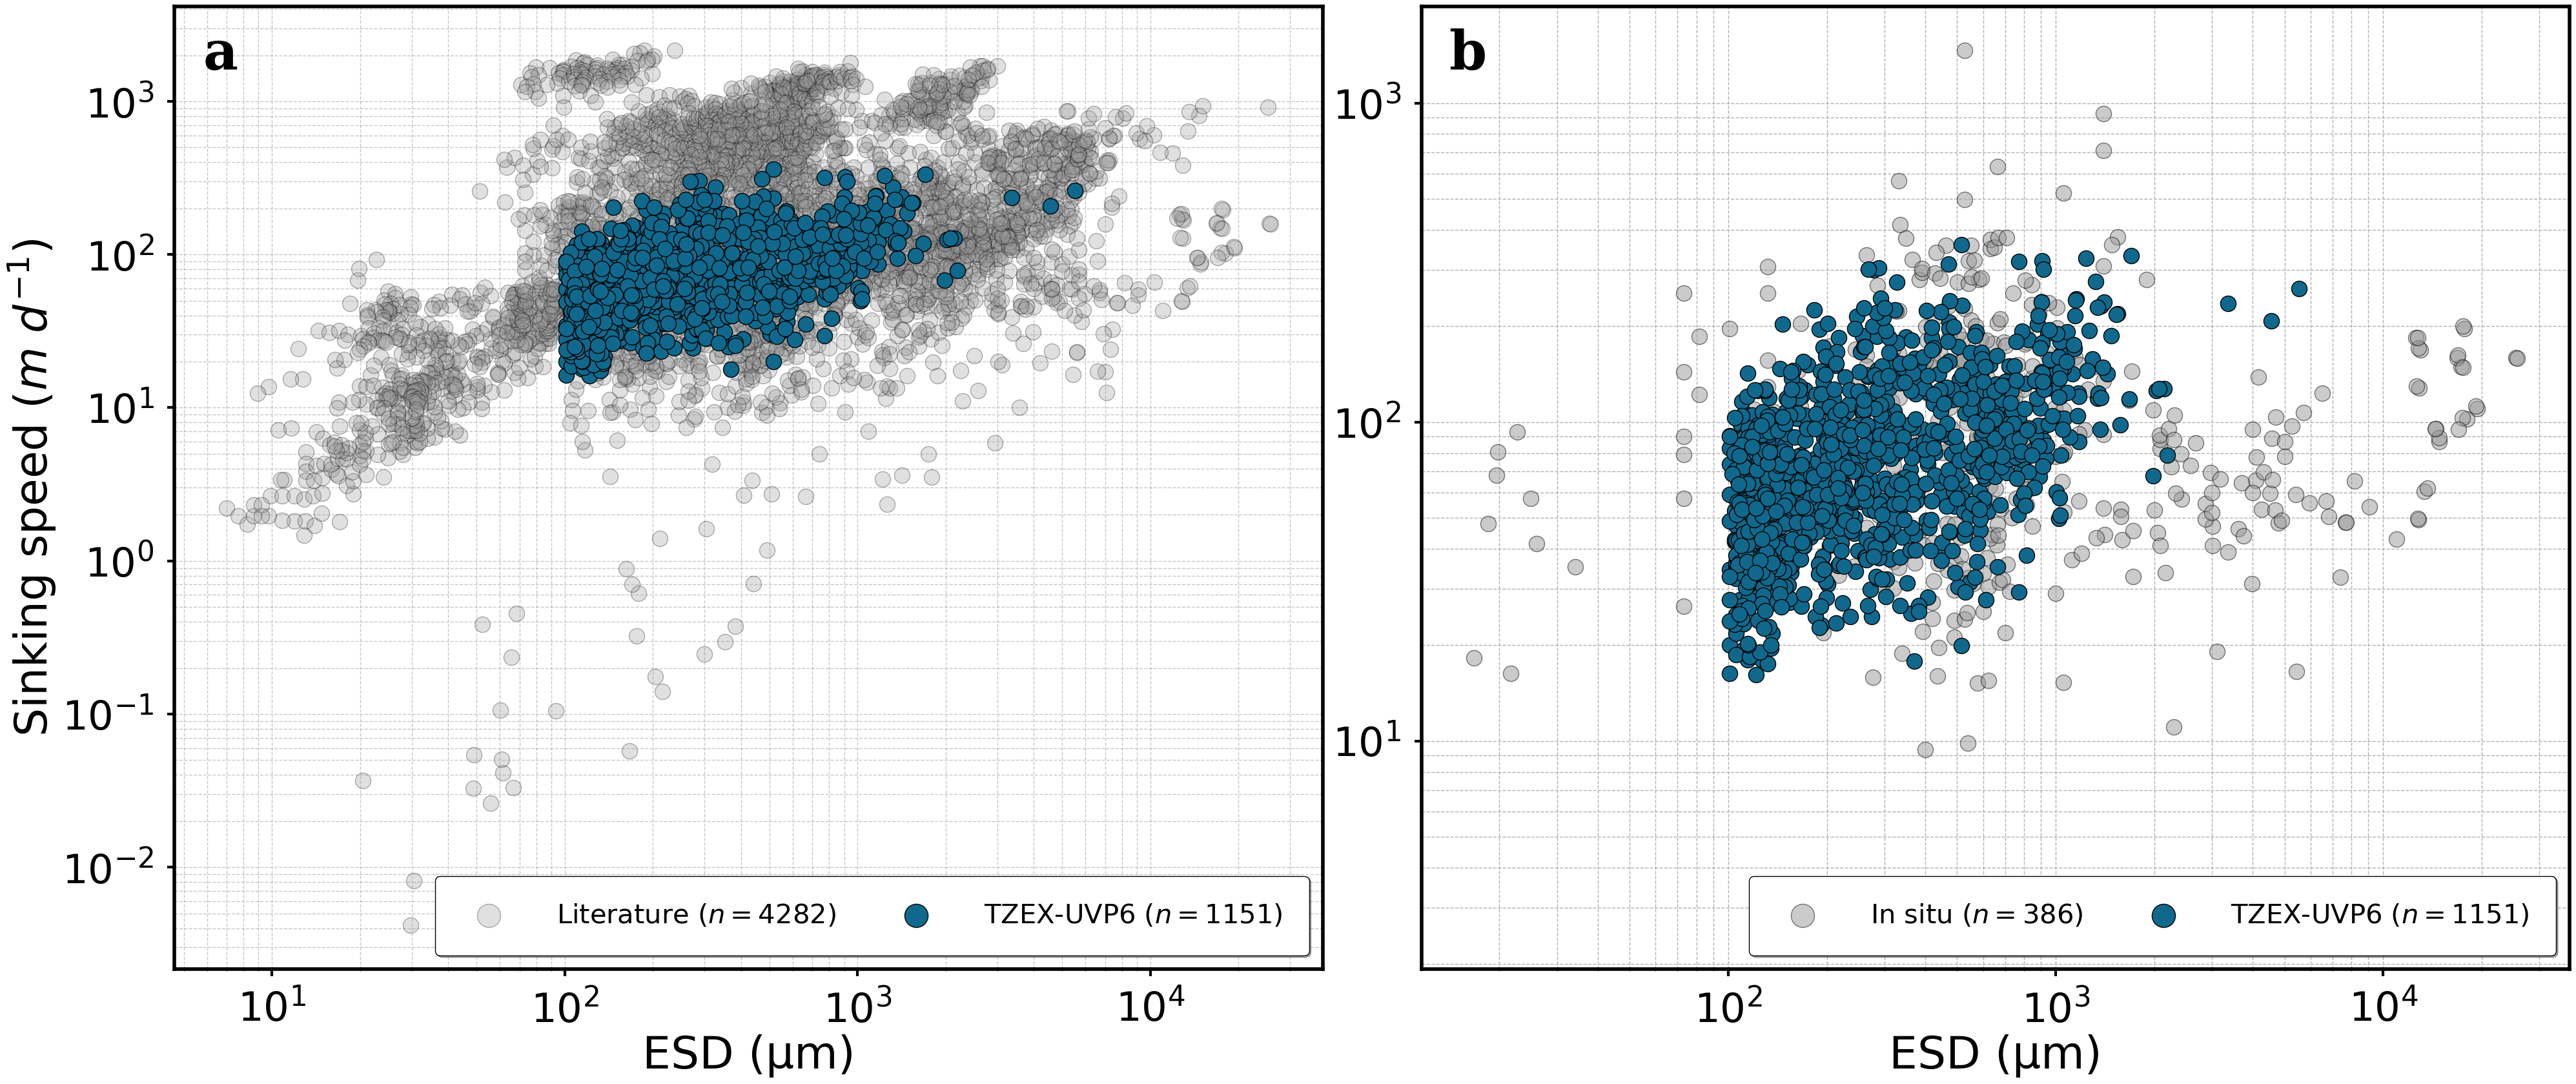

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(40, 18))

# Plot in position 0,0
plot_sinking_speeds(desc_tracks, xaxis_label = 'ESD (µm)', yaxis_label = 'Sinking speed ($m$ $d^{-1}$)', subplot_indice = 'a',  ax=axs[0])

# Plot in position 0,1
plot_in_situ_sinking_speeds(desc_tracks_insitu, 'esd_um', 'speed', 'zone', 'ESD (µm)', '', subplot_indice = 'b', ax=axs[1])

plt.tight_layout()
plt.subplots_adjust(top=0.93)

plt.savefig(f'/home/aaccardo/these_alex/Papers/Rising_stars/Figure_3/Figure_3.png', dpi = 300)

plt.show()